# Superposition and Entanglement in Qiskit
This notebook demonstrates:
1. **Superposition** using a single qubit.
2. **Entanglement** using two qubits.
We will use Qiskit to create circuits, visualize the states, and measure outcomes.

In [1]:
# ===========================
# Install Qiskit, Aer and pylatexenc
# ===========================
!pip install qiskit --quiet
!pip install qiskit-aer --quiet


In [2]:
# ===========================
# Import Libraries
# ===========================
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# Use AerSimulator
simulator = AerSimulator()

## 1. Superposition Example


TASK 1: Superposition — |+> = (|0> + |1>)/√2

     ┌───┐
  q: ┤ H ├
     └───┘
c: 1/═════
          


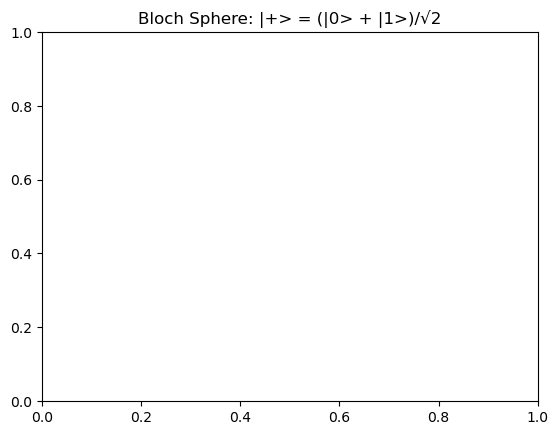

Measurement Counts: {'0': 476, '1': 548}


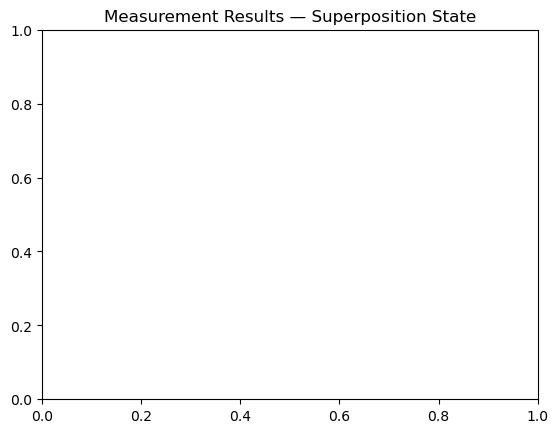

In [5]:
# ================================================
# TASK 1: Superposition — |+> = (|0> + |1>)/√2
# ================================================

print("\nTASK 1: Superposition — |+> = (|0> + |1>)/√2\n")

# Step 1: Create a 1-qubit circuit
qc_super = QuantumCircuit(1, 1)

# Step 2: Apply Hadamard gate to create superposition
qc_super.h(0)

# Step 3: Visualize the circuit
print(qc_super.draw("text"))

# Step 4: Get the statevector before measurement
state_super = Statevector.from_instruction(qc_super)
plot_bloch_multivector(state_super)
plt.title("Bloch Sphere: |+> = (|0> + |1>)/√2")
plt.show()

# Step 5: Explicit measurement (avoid measure_all duplication)
qc_super.measure(0, 0)

# Step 6: Run simulation
tqc_super = transpile(qc_super, simulator)
job_super = simulator.run(tqc_super, shots=1024)
result_super = job_super.result()
counts_super = result_super.get_counts()

print("Measurement Counts:", counts_super)

# Step 7: Plot histogram
plot_histogram(counts_super)
plt.title("Measurement Results — Superposition State")
plt.show()


## 2. Entanglement Example


TASK 2: Entanglement — Bell State |Φ⁺> = (|00> + |11>)/√2

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               
Entangled Statevector:
 Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


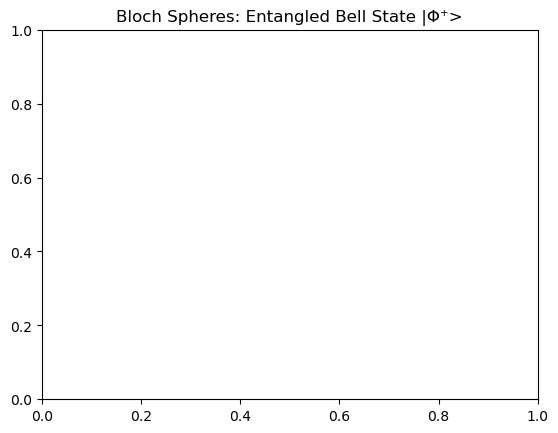

Measurement Counts: {'11': 527, '00': 497}


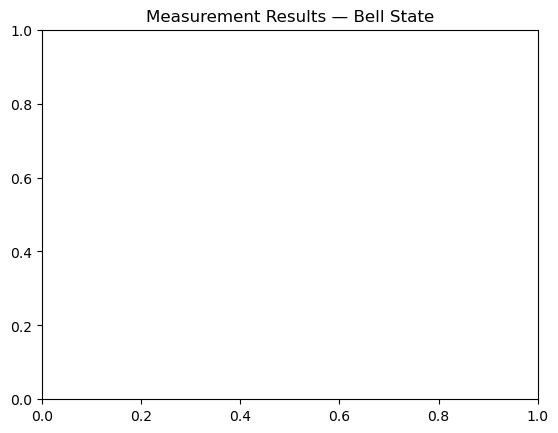

In [7]:
# ================================================
# TASK 2: Entanglement — Bell State |Φ⁺> = (|00> + |11>)/√2
# ================================================

print("\nTASK 2: Entanglement — Bell State |Φ⁺> = (|00> + |11>)/√2\n")

# Step 1: Create a 2-qubit circuit
qc_ent = QuantumCircuit(2, 2)

# Step 2: Apply Hadamard on qubit 0, then CNOT (0 → 1)
qc_ent.h(0)
qc_ent.cx(0, 1)

# Step 3: Visualize the circuit
print(qc_ent.draw("text"))

# Step 4: Get statevector before measurement
state_ent = Statevector.from_instruction(qc_ent)
print("Entangled Statevector:\n", state_ent)
plot_bloch_multivector(state_ent)
plt.title("Bloch Spheres: Entangled Bell State |Φ⁺>")
plt.show()

# Step 5: Explicit measurement (avoid measure_all duplication)
qc_ent.measure([0, 1], [0, 1])

# Step 6: Run simulation
tqc_ent = transpile(qc_ent, simulator)
job_ent = simulator.run(tqc_ent, shots=1024)
result_ent = job_ent.result()
counts_ent = result_ent.get_counts()

print("Measurement Counts:", counts_ent)

# Step 7: Plot histogram
plot_histogram(counts_ent)
plt.title("Measurement Results — Bell State")
plt.show()
